In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

процент дефолта - ~22, это видно внизу, можно сделать график который показывает, как изменился процент дефолта после обучения модели 

In [8]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'credit_risk_dataset.csv')
print(df['loan_status'].value_counts())

print(df['loan_status'].value_counts(normalize=True))

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


в репорте можно посмотреть accuracy что является долей правильных ответов НО очень зависит от дисбаланса классов и на нее опираться скорее ошибка, но ее в теории можно привести в противовес проценту дефолта без модели. То есть у нас процент дефолта и процент того, что модель будет права в своем утверждении. => В теории дефолт сократится с 22 процентов до 16. Вообще в таком случае нам важна точность - Пресижн

<Axes: xlabel='Stage', ylabel='Percent_of_error'>

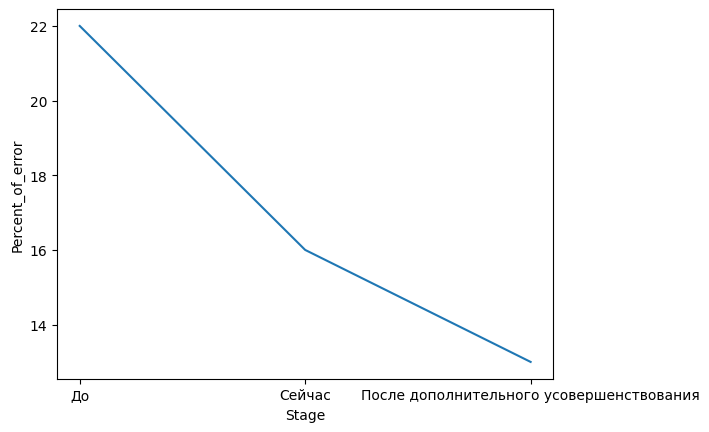

In [ ]:
data = {'Stage': ['До', 'Сейчас', 'После дополнительного усовершенствования'], 'Percent_of_error': [22, 16, 13]}
df_data = pd.DataFrame(data)
sns.lineplot(data=df_data, x="Stage", y="Percent_of_error")

По текущим данным это сократило бы потери денег на = средняя сумма кредита * процент дефолта * количество людей в датасете
Но также т к мы используем accuracy а она рассчитывается исходя из данных о любых ошибках - и ложно отрицательные - кредит вернули бы, а мы его не выдали, и ложно положительные - кредит не вернут, а мы его выдали, ложно положительные спасают от лишних, не выданных кредитов, ложно отрицательные несут нам убыток. ТО ЕСТЬ Часть ошибки это не дефолт по кредиту, а просто не выданный кредит ошибочно

<Axes: xlabel='Stage', ylabel='Sum_of_error'>

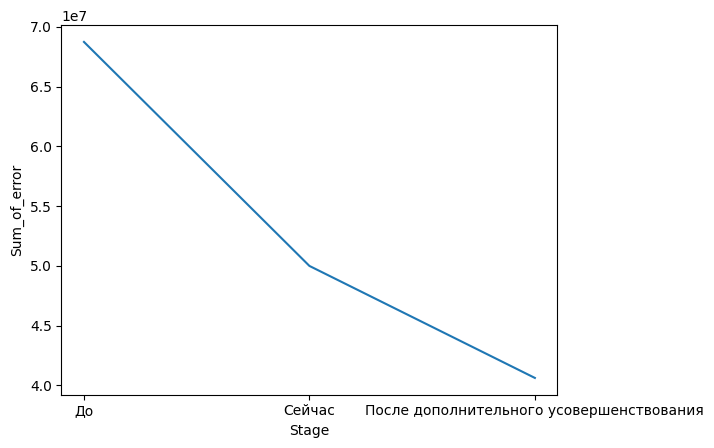

In [17]:
data = {
    'Stage': ['До', 'Сейчас', 'После дополнительного усовершенствования'], 
    'Sum_of_error': [
        df['loan_amnt'].mean() * len(df) * 0.22, 
        df['loan_amnt'].mean() * len(df) * 0.16, 
        df['loan_amnt'].mean() * len(df) * 0.13
    ]
}
df_loan_amnt = pd.DataFrame(data)
sns.lineplot(data=df_loan_amnt, x="Stage", y="Sum_of_error")


Нулевая гипотеза - цель кредита медицина не влияет на вероятность возврата кредита.
Альтернативная гипотеза - заемщики с целью кредита медицина чаще отдают кредит.

In [18]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
medical = df[df['loan_intent'] == 'MEDICAL']['loan_status'] # берем строки, где цель - медикал
others = df[df['loan_intent'] != 'MEDICAL']['loan_status'] # все остальные

In [23]:
count = [medical.sum(), others.sum()]  # количество дефолтов в группах
nobs = [len(medical), len(others)]    # общее количество заемщиков в группах
count, nobs

([np.int64(1621), np.int64(5487)], [6071, 26510])

In [21]:
stat, p_value = proportions_ztest(count, nobs, alternative='smaller')

print(f"Средний процент дефолта (Медицина): {medical.mean():.2%}")
print(f"Средний процент дефолта (Остальные): {others.mean():.2%}")
print(f"P-value: {p_value:.4f}")

Средний процент дефолта (Медицина): 26.70%
Средний процент дефолта (Остальные): 20.70%
P-value: 1.0000


исходя из данных выше уже можно сказать, что утверждение: медицинские кредиты выплачивают чаще - неверное

In [22]:
alpha = 0.05
if p_value < alpha:
    print("Результат: Отвергаем нулевую гипотезу. Цель 'Медицина' статистически влияет на возврат.")
else:
    print("Результат: Не удалось отвергнуть нулевую гипотезу. Значимых различий не обнаружено.")

Результат: Не удалось отвергнуть нулевую гипотезу. Значимых различий не обнаружено.
